# Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator


In [ ]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler


def pm_for_backend(bknd, opt_level, seed=42069, schedueling_method="alap"):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=schedueling_method)
    return pm


def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return [id, summary]


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    # Default Sequence
    sequenece = [XGate(), XGate()]

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
        
    return pm




def transpile_for_dd(circuit, dd_pm, backend):
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]




def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend)),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = list(target.operations)

    if target is not None:
        summary["supported_instructions"] = list(target.operations)

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary

## Circuit generation and transpilation

In [9]:
## Prepare circuit dict
circuit_dict = {f"{i}":prepare_echo_ghz_with_xs(n_qubits=i) for i in range(7, 11)}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x70f34b02dfd0>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x70f35b3f60d0>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x70f34b02d090>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x70f34b02c910>}

In [10]:
## Transpile circuit for torino backend
service = QiskitRuntimeService(name="qamp-2025")

marrakesh = service.backend("ibm_marrakesh")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(marrakesh, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{i}":pm3.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

## Transpile for DD

dd_xpxm_pm = prepare_dd_pm(marrakesh, seq="XpXm", scheduling_method="alap")

dd_xx_pm = prepare_dd_pm(marrakesh, seq="XX", scheduling_method="alap")


isa_dd_xpxm_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xpxm_pm, marrakesh) for i in range(7, 11)}

isa_dd_xx_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xx_pm, marrakesh) for i in range(7, 11)}


print(isa_dict)



management.get:WARNING:2025-11-30 02:51:14,039: Loading saved account: qamp-2025


{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x70f359811fd0>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x70f359846dd0>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x70f3598698d0>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x70f35a0ed490>}


In [11]:
isa_dict["7"].draw(fold=-1)

global phase: π/2
           ┌───────────────┐ ┌─────────┐   ┌────┐  ┌───────┐                                                                      ┌────┐     ┌─────────┐   ┌───────────────┐                                                                         ░  ░ ┌───────────────┐                                                                                                  ┌─────────┐   ┌────┐ ┌───────┐    ┌───────────────┐┌────┐┌─────────┐                                                                          ░ ┌───┐ ░          ┌─┐         
 q_3 -> 91 ┤ Delay(52[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├──────────────────────────────────────────────────────────────■───────┤ √X ├─────┤ Rz(π/2) ├─■─┤ Delay(61[dt]) ├─────────────────────────────────────────────────────────────────────────░──░─┤ Delay(61[dt]) ├─────────────────────────────────────────────────────────────────────────────────────────────■────┤ Rz(π/2) ├───┤ √X ├─┤ Rz(π) ├──■─┤ Delay(52[dt]) ├┤ √X ├┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                              │       └────┘     └─────────┘ │ └─────┬────┬────┘┌─────────┐   ┌───────────────┐                                          ░  ░ ├───────────────┤                                                            ┌─────────┐    ┌────┐ ┌───────┐  │ ┌──┴─────────┴──┐├────┤┌┴───────┴┐ │ └───────────────┘└────┘└─────────┘                                                                          ░ ├───┤ ░          └╥┘┌─┐      
 q_4 -> 92 ┤ Delay(78[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├──────────────────────────────────────────────────────────────┼──────────────────────────────■───────┤ √X ├─────┤ Rz(π/2) ├─■─┤ Delay(35[dt]) ├──────────────────────────────────────────░──░─┤ Delay(35[dt]) ├───────────────────────────────────────────────────────■────┤ Rz(π/2) ├────┤ √X ├─┤ Rz(π) ├──■─┤ Delay(78[dt]) ├┤ √X ├┤ Rz(π/2) ├─┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫─┤M├──────
           ├───────────────┴┐├─────────┤   ├────┤  ├───────┤                                                              │                                      └────┘     └─────────┘ │ └─────┬────┬────┘┌─────────┐   ┌──────────────┐            ░  ░ └┬──────────────┤                      ┌─────────┐    ┌────┐ ┌───────┐  │ ┌──┴─────────┴───┐├────┤┌┴───────┴┐   └───────────────┘└────┘└─────────┘ │                                                                                                             ░ ├───┤ ░           ║ └╥┘┌─┐   
 q_5 -> 93 ┤ Delay(104[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├──────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────■───────┤ √X ├─────┤ Rz(π/2) ├─■─┤ Delay(9[dt]) ├────────────░──░──┤ Delay(9[dt]) ├─────────────────■────┤ Rz(π/2) ├────┤ √X ├─┤ Rz(π) ├──■─┤ Delay(104[dt]) ├┤ √X ├┤ Rz(π/2) ├──────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫──╫─┤M├───
           ├────────────────┤├─────────┤   ├────┤  ├───────┤                                                              │                                                                     └────┘     └─────────┘ │ └────┬────┬────┘┌─────────┐ ░  ░  └─┬─────────┬──┘ ┌────┐┌───────┐ │ ┌──┴─────────┴───┐├────┤┌┴───────┴┐   └────────────────┘└────┘└─────────┘                                      │                                                                                                             ░ ├───┤ ░           ║  ║ └╥┘┌─┐
 q_6 -> 94 ┤ Delay(130[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├──────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────────────────────────

In [12]:
isa_dd_xpxm_dict["7"].draw(idle_wires=False, fold=-1)

global phase: π/2
           ┌───────────────┐ ┌─────────┐   ┌────┐  ┌───────┐                                                                                                      ┌────┐        ┌─────────┐                    ┌───────────────┐      ┌───┐      ┌───────────────┐     ┌───┐      ┌───────────────┐                                                 ░  ░ ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐                                                                            ┌─────────┐   ┌────┐    ┌───────┐             ┌──────────────┐┌───┐ ┌───────────────┐┌───┐┌──────────────┐┌────┐  ┌─────────┐                                               ░ ┌───┐ ░          ┌─┐         
 q_3 -> 91 ┤ Delay(52[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(10[dt]) ├──────┤ X ├──────┤ Delay(23[dt]) ├─────┤ X ├──────┤ Delay(10[dt]) ├─────────────────────────────────────────────────░──░─┤ Delay(10[dt]) ├┤ X ├─┤ Delay(23[dt]) ├┤ X ├┤ Delay(10[dt]) ├──────────────────────────────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────────■──┤ Delay(8[dt]) ├┤ X ├─┤ Delay(18[dt]) ├┤ X ├┤ Delay(8[dt]) ├┤ √X ├──┤ Rz(π/2) ├───────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                                                       │              └────┘        └─────────┘           │        └─────┬────┬────┘   ┌──┴───┴──┐   └───────────────┘┌────┴───┴─────┐└─────┬───┬─────┘┌──────────────┐     ┌───┐      ┌──────────────┐ ░  ░ └┬──────────────┤├───┤ └┬──────────────┤├───┤└┬──────────────┤                               ┌─────────┐   ┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐ │ ┌┴──────────────┤├───┴┐└──┬─────────┬──┘└───┘└──────────────┘└────┘  └─────────┘                                               ░ ├───┤ ░          └╥┘┌─┐      
 q_4 -> 92 ┤ Delay(78[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(4[dt]) ├──────┤ X ├──────┤ Delay(9[dt]) ├─────┤ X ├──────┤ Delay(4[dt]) ├─░──░──┤ Delay(4[dt]) ├┤ X ├──┤ Delay(9[dt]) ├┤ X ├─┤ Delay(4[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(15[dt]) ├┤ X ├─┤ Delay(30[dt]) ├┤ X ├─┼─┤ Delay(15[dt]) ├┤ √X ├───┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫─┤M├──────
           ├───────────────┴┐├─────────┤   ├────┤  ├───────┤                                                                                       │                                                                 └────┘        └─────────┘           │        └────┬────┬────┘   ┌──┴───┴──┐   └──────────────┘┌────┴───┴─────┐└──────────────┘ ░  ░  ├──────────────┤└───┘  └──────────────┘└───┘ └─┬─────────┬──┘┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐├───────────────┤├───┴┐└──┬─────────┬──┘└───┘ │ └───────────────┘└────┘   └─────────┘                                                                                          ░ ├───┤ ░           ║ └╥┘┌─┐   
 q_5 -> 93 ┤ Delay(104[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├──────────■────────┤ Delay(9[dt]) ├─────────────────░──░──┤ Delay(9[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(21[dt]) ├┤ X ├─┤ Delay(44[dt]) ├┤ X ├┤ Delay(21[dt]) ├┤ √X ├───┤ Rz(π/2) ├─────────┼────────────────────

In [13]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()

noiseless_pub = [(isa_dict[f"{i}"]) for i in range(7, 11)]


with Batch(backend=noiseless_backend) as batch:
    noiseless_sampler = naked_sampler(mode=batch)
    noiseless_job = noiseless_sampler.run(noiseless_pub, shots=4096)
    noiseless_result = noiseless_job.result()




/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [14]:
simulated_counts = {f"{i+7}":noiseless_result[i].data.meas.get_counts() for i in range(0,4)}
simulated_counts

{'7': {'1111111': 4096},
 '8': {'11111111': 4096},
 '9': {'111111111': 4096},
 '10': {'1111111111': 4096}}

In [9]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{i}":[(isa_dict[f"{i}"]), (isa_dd_xx_dict[f"{i}"]), (isa_dd_xpxm_dict[f"{i}"])] for i in range(7, 11)}
pub_hardware_dict

{'7': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7018cf14d010>,
 '8': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7018cef83ad0>,
 '9': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7018cefaca90>,
 '10': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7018cec17110>,
  <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7018cef78390>]}

# Hardware Execution Cell. Do not run unless required

In [ ]:
## Executing experiments with iterations = 5. Total circuit to run = 5*4 = 20
# hardware_job_dict = {f"{iter}":{f"{i}":execute_on_hardware(marrakesh, pub_hardware_dict[f"{i}"]) for i in range(7, 11)} for iter in range(0, 5 )}

d4kbdlt74pkc7386sf10
d4kbdml74pkc7386sf2g
d4kbdn574pkc7386sf40
d4kbdnp0i6jc73delf10
d4kbdok3tdfc73dob19g
d4kbdp43tdfc73dob1bg
d4kbdq43tdfc73dob1cg
d4kbdqp0i6jc73delf5g
d4kbdrh0i6jc73delf6g
d4kbdsav0j9c73e46hf0
d4kbdsp0i6jc73delf80
d4kbdth0i6jc73delf9g
d4kbduc3tdfc73dob1j0
d4kbdv43tdfc73dob1k0
d4kbdvk3tdfc73dob1l0
d4kbe0574pkc7386sfd0
d4kbe0t74pkc7386sfeg
d4kbe1k3tdfc73dob1ng
d4kbe243tdfc73dob1p0
d4kbe2p0i6jc73delff0


In [11]:
hardware_job_dict

{'0': {'7': ['d4kbdlt74pkc7386sf10',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 

Above are the job-ids of experiments. Used these to get the Result Objects. 

# Cell Too Long. Keep it closed

In [3]:
hardware_job_dict = {'0': {'7': ['d4kbdlt74pkc7386sf10',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '8': ['d4kbdml74pkc7386sf2g',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '9': ['d4kbdn574pkc7386sf40',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '10': ['d4kbdnp0i6jc73delf10',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}]},
 '1': {'7': ['d4kbdok3tdfc73dob19g',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '8': ['d4kbdp43tdfc73dob1bg',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '9': ['d4kbdq43tdfc73dob1cg',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '10': ['d4kbdqp0i6jc73delf5g',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}]},
 '2': {'7': ['d4kbdrh0i6jc73delf6g',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '8': ['d4kbdsav0j9c73e46hf0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '9': ['d4kbdsp0i6jc73delf80',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '10': ['d4kbdth0i6jc73delf9g',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}]},
 '3': {'7': ['d4kbduc3tdfc73dob1j0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '8': ['d4kbdv43tdfc73dob1k0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '9': ['d4kbdvk3tdfc73dob1l0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '10': ['d4kbe0574pkc7386sfd0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}]},
 '4': {'7': ['d4kbe0t74pkc7386sfeg',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '8': ['d4kbe1k3tdfc73dob1ng',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '9': ['d4kbe243tdfc73dob1p0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}],
  '10': ['d4kbe2p0i6jc73delff0',
   {'backend_name': 'ibm_marrakesh',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Delay(duration=t[unit=dt]),
     Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
     [8, 9],
     [9, 8],
     [9, 10],
     [10, 9],
     [10, 11],
     [11, 10],
     [11, 12],
     [11, 18],
     [12, 11],
     [12, 13],
     [13, 12],
     [13, 14],
     [14, 13],
     [14, 15],
     [15, 14],
     [15, 19],
     [16, 3],
     [16, 23],
     [17, 7],
     [17, 27],
     [18, 11],
     [18, 31],
     [19, 15],
     [19, 35],
     [20, 21],
     [21, 20],
     [21, 22],
     [21, 36],
     [22, 21],
     [22, 23],
     [23, 16],
     [23, 22],
     [23, 24],
     [24, 23],
     [24, 25],
     [25, 24],
     [25, 26],
     [25, 37],
     [26, 25],
     [26, 27],
     [27, 17],
     [27, 26],
     [27, 28],
     [28, 27],
     [28, 29],
     [29, 28],
     [29, 30],
     [29, 38],
     [30, 29],
     [30, 31],
     [31, 18],
     [31, 30],
     [31, 32],
     [32, 31],
     [32, 33],
     [33, 32],
     [33, 34],
     [33, 39],
     [34, 33],
     [34, 35],
     [35, 19],
     [35, 34],
     [36, 21],
     [36, 41],
     [37, 25],
     [37, 45],
     [38, 29],
     [38, 49],
     [39, 33],
     [39, 53],
     [40, 41],
     [41, 36],
     [41, 40],
     [41, 42],
     [42, 41],
     [42, 43],
     [43, 42],
     [43, 44],
     [43, 56],
     [44, 43],
     [44, 45],
     [45, 37],
     [45, 44],
     [45, 46],
     [46, 45],
     [46, 47],
     [47, 46],
     [47, 48],
     [47, 57],
     [48, 47],
     [48, 49],
     [49, 38],
     [49, 48],
     [49, 50],
     [50, 49],
     [50, 51],
     [51, 50],
     [51, 52],
     [51, 58],
     [52, 51],
     [52, 53],
     [53, 39],
     [53, 52],
     [53, 54],
     [54, 53],
     [54, 55],
     [55, 54],
     [55, 59],
     [56, 43],
     [56, 63],
     [57, 47],
     [57, 67],
     [58, 51],
     [58, 71],
     [59, 55],
     [59, 75],
     [60, 61],
     [61, 60],
     [61, 62],
     [61, 76],
     [62, 61],
     [62, 63],
     [63, 56],
     [63, 62],
     [63, 64],
     [64, 63],
     [64, 65],
     [65, 64],
     [65, 66],
     [65, 77],
     [66, 65],
     [66, 67],
     [67, 57],
     [67, 66],
     [67, 68],
     [68, 67],
     [68, 69],
     [69, 68],
     [69, 70],
     [69, 78],
     [70, 69],
     [70, 71],
     [71, 58],
     [71, 70],
     [71, 72],
     [72, 71],
     [72, 73],
     [73, 72],
     [73, 74],
     [73, 79],
     [74, 73],
     [74, 75],
     [75, 59],
     [75, 74],
     [76, 61],
     [76, 81],
     [77, 65],
     [77, 85],
     [78, 69],
     [78, 89],
     [79, 73],
     [79, 93],
     [80, 81],
     [81, 76],
     [81, 80],
     [81, 82],
     [82, 81],
     [82, 83],
     [83, 82],
     [83, 84],
     [83, 96],
     [84, 83],
     [84, 85],
     [85, 77],
     [85, 84],
     [85, 86],
     [86, 85],
     [86, 87],
     [87, 86],
     [87, 88],
     [87, 97],
     [88, 87],
     [88, 89],
     [89, 78],
     [89, 88],
     [89, 90],
     [90, 89],
     [90, 91],
     [91, 90],
     [91, 92],
     [91, 98],
     [92, 91],
     [92, 93],
     [93, 79],
     [93, 92],
     [93, 94],
     [94, 93],
     [94, 95],
     [95, 94],
     [95, 99],
     [96, 83],
     [96, 103],
     [97, 87],
     [97, 107],
     [98, 91],
     [98, 111],
     [99, 95],
     [99, 115],
     [100, 101],
     [101, 100],
     [101, 102],
     [101, 116],
     [102, 101],
     [102, 103],
     [103, 96],
     [103, 102],
     [103, 104],
     [104, 103],
     [104, 105],
     [105, 104],
     [105, 106],
     [105, 117],
     [106, 105],
     [106, 107],
     [107, 97],
     [107, 106],
     [107, 108],
     [108, 107],
     [108, 109],
     [109, 108],
     [109, 110],
     [109, 118],
     [110, 109],
     [110, 111],
     [111, 98],
     [111, 110],
     [111, 112],
     [112, 111],
     [112, 113],
     [113, 112],
     [113, 114],
     [113, 119],
     [114, 113],
     [114, 115],
     [115, 99],
     [115, 114],
     [116, 101],
     [116, 121],
     [117, 105],
     [117, 125],
     [118, 109],
     [118, 129],
     [119, 113],
     [119, 133],
     [120, 121],
     [121, 116],
     [121, 120],
     [121, 122],
     [122, 121],
     [122, 123],
     [123, 122],
     [123, 124],
     [123, 136],
     [124, 123],
     [124, 125],
     [125, 117],
     [125, 124],
     [125, 126],
     [126, 125],
     [126, 127],
     [127, 126],
     [127, 128],
     [127, 137],
     [128, 127],
     [128, 129],
     [129, 118],
     [129, 128],
     [129, 130],
     [130, 129],
     [130, 131],
     [131, 130],
     [131, 132],
     [131, 138],
     [132, 131],
     [132, 133],
     [133, 119],
     [133, 132],
     [133, 134],
     [134, 133],
     [134, 135],
     [135, 134],
     [135, 139],
     [136, 123],
     [136, 143],
     [137, 127],
     [137, 147],
     [138, 131],
     [138, 151],
     [139, 135],
     [139, 155],
     [140, 141],
     [141, 140],
     [141, 142],
     [142, 141],
     [142, 143],
     [143, 136],
     [143, 142],
     [143, 144],
     [144, 143],
     [144, 145],
     [145, 144],
     [145, 146],
     [146, 145],
     [146, 147],
     [147, 137],
     [147, 146],
     [147, 148],
     [148, 147],
     [148, 149],
     [149, 148],
     [149, 150],
     [150, 149],
     [150, 151],
     [151, 138],
     [151, 150],
     [151, 152],
     [152, 151],
     [152, 153],
     [153, 152],
     [153, 154],
     [154, 153],
     [154, 155],
     [155, 139],
     [155, 154]],
    'qubit_properties': [{'qubit': 0,
      't1': 366.2771372994965,
      't2': 41.74377816503369,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 1,
      't1': 79.16046337625518,
      't2': 73.01616617861839,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 2,
      't1': 315.7729711423096,
      't2': 417.2758857836166,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 3,
      't1': 339.26079387994713,
      't2': 299.196355229976,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 4,
      't1': 196.63458081203737,
      't2': 125.46679143414568,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 5,
      't1': 162.17027727906645,
      't2': 122.34143478411941,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 6,
      't1': 234.7803470924423,
      't2': 128.5641478677964,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 7,
      't1': 298.74218609051195,
      't2': 96.11324251740857,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 8,
      't1': 152.46784798100632,
      't2': 77.06067141585429,
      'frequency': None,
      'readout_error': 0.0128173828125},
     {'qubit': 9,
      't1': 144.0636406362054,
      't2': 45.76747628779937,
      'frequency': None,
      'readout_error': 0.00830078125},
     {'qubit': 10,
      't1': 271.8862229848225,
      't2': 168.5983744117843,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 11,
      't1': 388.6241211514959,
      't2': 168.11196180229317,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 12,
      't1': 251.57710759500708,
      't2': 188.36008246509894,
      'frequency': None,
      'readout_error': 0.0035400390625},
     {'qubit': 13,
      't1': 183.23620069368266,
      't2': 223.19225821390816,
      'frequency': None,
      'readout_error': 0.1243896484375},
     {'qubit': 14,
      't1': 242.65319886544123,
      't2': 122.15483554511205,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 15,
      't1': 238.19503342596084,
      't2': 29.267135895192872,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 16,
      't1': 150.78301139758537,
      't2': 83.01210688097942,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 17,
      't1': 168.73262088620254,
      't2': 10.045961018816644,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 18,
      't1': 82.90674088914521,
      't2': 70.58201790269577,
      'frequency': None,
      'readout_error': 0.015380859375},
     {'qubit': 19,
      't1': 139.87551547337517,
      't2': 67.98222000823779,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 20,
      't1': 128.7339722707705,
      't2': 150.15988198532108,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 21,
      't1': 332.25921956029237,
      't2': 205.0824876734603,
      'frequency': None,
      'readout_error': 0.01171875},
     {'qubit': 22,
      't1': 67.98404785503037,
      't2': 22.727647023657518,
      'frequency': None,
      'readout_error': 0.004638671875},
     {'qubit': 23,
      't1': 226.33814021478761,
      't2': 169.8308242659261,
      'frequency': None,
      'readout_error': 0.0384521484375},
     {'qubit': 24,
      't1': 154.4451663093713,
      't2': 75.64453739745532,
      'frequency': None,
      'readout_error': 0.017822265625},
     {'qubit': 25,
      't1': 136.9349630475466,
      't2': 57.8337834511632,
      'frequency': None,
      'readout_error': 0.0186767578125},
     {'qubit': 26,
      't1': 5.856089419087943,
      't2': 7.9597559730978364,
      'frequency': None,
      'readout_error': 0.0491943359375},
     {'qubit': 27,
      't1': 175.5182712759119,
      't2': 142.43708202683055,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 28,
      't1': 349.90863930298127,
      't2': 91.51490189586528,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 29,
      't1': 51.76440334169723,
      't2': 59.28498165690049,
      'frequency': None,
      'readout_error': 0.0281982421875},
     {'qubit': 30,
      't1': 287.03433146701394,
      't2': 28.95682112425268,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 31,
      't1': 162.29860679789348,
      't2': 65.42322528015552,
      'frequency': None,
      'readout_error': 0.0479736328125},
     {'qubit': 32,
      't1': 191.32207046159618,
      't2': 36.09958258195637,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 33,
      't1': 160.1438290554607,
      't2': 162.62520282267366,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 34,
      't1': 167.58044193493578,
      't2': 135.06756551433898,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 35,
      't1': 166.34580118006764,
      't2': 79.09309013171546,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 36,
      't1': 268.771882319113,
      't2': 85.2928505228903,
      'frequency': None,
      'readout_error': 0.01318359375},
     {'qubit': 37,
      't1': 143.68841287677125,
      't2': 15.710719458554694,
      'frequency': None,
      'readout_error': 0.0628662109375},
     {'qubit': 38,
      't1': 120.5153578836716,
      't2': 92.7848682811044,
      'frequency': None,
      'readout_error': 0.0040283203125},
     {'qubit': 39,
      't1': 177.9883718479112,
      't2': 101.06441350329071,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 40,
      't1': 197.57432517836597,
      't2': 37.20918107827581,
      'frequency': None,
      'readout_error': 0.155029296875},
     {'qubit': 41,
      't1': 138.20325283864742,
      't2': 33.75634797118007,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 42,
      't1': 288.8248169645412,
      't2': 167.6861627838606,
      'frequency': None,
      'readout_error': 0.0064697265625},
     {'qubit': 43,
      't1': 219.52617491192152,
      't2': 92.37222729249116,
      'frequency': None,
      'readout_error': 0.014404296875},
     {'qubit': 44,
      't1': 148.3946285933817,
      't2': 33.542613681865326,
      'frequency': None,
      'readout_error': 0.008544921875},
     {'qubit': 45,
      't1': 80.81695231554409,
      't2': 91.97628445653618,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 46,
      't1': 277.77655601360186,
      't2': 65.54799198039201,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 47,
      't1': 285.8511436047071,
      't2': 195.85239193523046,
      'frequency': None,
      'readout_error': 0.025634765625},
     {'qubit': 48,
      't1': 167.35091434965656,
      't2': 172.07756529137873,
      'frequency': None,
      'readout_error': 0.0670166015625},
     {'qubit': 49,
      't1': 196.5751039044005,
      't2': 186.13198261433132,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 50,
      't1': 191.56409846296822,
      't2': 177.26719567951903,
      'frequency': None,
      'readout_error': 0.0115966796875},
     {'qubit': 51,
      't1': 245.2687666607062,
      't2': 291.64659093972483,
      'frequency': None,
      'readout_error': 0.046875},
     {'qubit': 52,
      't1': 151.05287550618687,
      't2': 114.73278774083448,
      'frequency': None,
      'readout_error': 0.0069580078125},
     {'qubit': 53,
      't1': 208.11567698326377,
      't2': 211.3635356720778,
      'frequency': None,
      'readout_error': 0.0355224609375},
     {'qubit': 54,
      't1': 243.47118756465443,
      't2': 316.2354907607917,
      'frequency': None,
      'readout_error': 0.003662109375},
     {'qubit': 55,
      't1': 221.2759513635308,
      't2': 71.30465345945294,
      'frequency': None,
      'readout_error': 0.021728515625},
     {'qubit': 56,
      't1': 192.27738136909082,
      't2': 63.624429069973495,
      'frequency': None,
      'readout_error': 0.011474609375},
     {'qubit': 57,
      't1': 268.7977756199496,
      't2': 161.71183113928154,
      'frequency': None,
      'readout_error': 0.01513671875},
     {'qubit': 58,
      't1': 259.0489292625517,
      't2': 276.8106272686685,
      'frequency': None,
      'readout_error': 0.035400390625},
     {'qubit': 59,
      't1': 165.3722835039508,
      't2': 174.79858849598426,
      'frequency': None,
      'readout_error': 0.010498046875},
     {'qubit': 60,
      't1': 143.68156513632889,
      't2': 122.50703015899867,
      'frequency': None,
      'readout_error': 0.066650390625},
     {'qubit': 61,
      't1': 254.69505332286028,
      't2': 236.06229996509757,
      'frequency': None,
      'readout_error': 0.013671875},
     {'qubit': 62,
      't1': 118.39102716438533,
      't2': 54.38639743496781,
      'frequency': None,
      'readout_error': 0.01708984375},
     {'qubit': 63,
      't1': 195.82814356587724,
      't2': 199.34536718074077,
      'frequency': None,
      'readout_error': 0.0330810546875},
     {'qubit': 64,
      't1': 160.85549839143206,
      't2': 80.47128394466617,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 65,
      't1': 145.30919802294875,
      't2': 57.683190843221055,
      'frequency': None,
      'readout_error': 0.017578125},
     {'qubit': 66,
      't1': 136.52806246989675,
      't2': 120.17489102785335,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 67,
      't1': 331.1177296459768,
      't2': 79.27500233243092,
      'frequency': None,
      'readout_error': 0.030517578125},
     {'qubit': 68,
      't1': 48.83326703473527,
      't2': 34.82526726939281,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 69,
      't1': 127.95503225428,
      't2': 15.084117209076624,
      'frequency': None,
      'readout_error': 0.021240234375},
     {'qubit': 70,
      't1': 180.98418206996902,
      't2': 22.775083921081805,
      'frequency': None,
      'readout_error': 0.0106201171875},
     {'qubit': 71,
      't1': 184.323689145609,
      't2': 162.58958597127412,
      'frequency': None,
      'readout_error': 0.0103759765625},
     {'qubit': 72,
      't1': 127.21376162205986,
      't2': 62.92133927152093,
      'frequency': None,
      'readout_error': 0.013916015625},
     {'qubit': 73,
      't1': 161.04068709800345,
      't2': 138.53686386411988,
      'frequency': None,
      'readout_error': 0.0362548828125},
     {'qubit': 74,
      't1': 112.85962466354596,
      't2': 14.643955566629932,
      'frequency': None,
      'readout_error': 0.02099609375},
     {'qubit': 75,
      't1': 329.5724716723725,
      't2': 226.54500783515957,
      'frequency': None,
      'readout_error': 0.0059814453125},
     {'qubit': 76,
      't1': 125.41738739423167,
      't2': 52.11973874827086,
      'frequency': None,
      'readout_error': 0.0096435546875},
     {'qubit': 77,
      't1': 133.64307293663265,
      't2': 77.68779886029333,
      'frequency': None,
      'readout_error': 0.010009765625},
     {'qubit': 78,
      't1': 158.07357436410325,
      't2': 220.57588925929596,
      'frequency': None,
      'readout_error': 0.0081787109375},
     {'qubit': 79,
      't1': 108.80792609270262,
      't2': 48.45461029657004,
      'frequency': None,
      'readout_error': 0.085693359375},
     {'qubit': 80,
      't1': 189.6344223568989,
      't2': 46.734927237542344,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 81,
      't1': 122.58300464040441,
      't2': 128.15649212071895,
      'frequency': None,
      'readout_error': 0.0179443359375},
     {'qubit': 82,
      't1': 9.685004543900286,
      't2': 15.079302505251558,
      'frequency': None,
      'readout_error': 0.280029296875},
     {'qubit': 83,
      't1': 285.4492252185851,
      't2': 258.9076707360844,
      'frequency': None,
      'readout_error': 0.1121826171875},
     {'qubit': 84,
      't1': 146.45932191654381,
      't2': 138.5500797274292,
      'frequency': None,
      'readout_error': 0.0181884765625},
     {'qubit': 85,
      't1': 185.1168564494843,
      't2': 62.378279830621096,
      'frequency': None,
      'readout_error': 0.009033203125},
     {'qubit': 86,
      't1': 307.5172085706112,
      't2': 53.191805880471584,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 87,
      't1': 223.53290569494655,
      't2': 160.58263162775006,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 88,
      't1': 266.0599371812351,
      't2': 180.44932287380058,
      'frequency': None,
      'readout_error': 0.018798828125},
     {'qubit': 89,
      't1': 221.37068260255458,
      't2': 153.7829366391509,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 90,
      't1': 44.616566195812915,
      't2': 57.09980066096835,
      'frequency': None,
      'readout_error': 0.0247802734375},
     {'qubit': 91,
      't1': 139.09850925108145,
      't2': 233.89676435901004,
      'frequency': None,
      'readout_error': 0.00537109375},
     {'qubit': 92,
      't1': 141.0735879830864,
      't2': 88.36747906481108,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 93,
      't1': 267.69248851478466,
      't2': 206.78888339601988,
      'frequency': None,
      'readout_error': 0.112060546875},
     {'qubit': 94,
      't1': 290.8292881245074,
      't2': 280.6198630112613,
      'frequency': None,
      'readout_error': 0.0032958984375},
     {'qubit': 95,
      't1': 201.10846710215245,
      't2': 251.94791277694526,
      'frequency': None,
      'readout_error': 0.0147705078125},
     {'qubit': 96,
      't1': 129.76694570809238,
      't2': 38.88401897317757,
      'frequency': None,
      'readout_error': 0.0435791015625},
     {'qubit': 97,
      't1': 223.79976339169883,
      't2': 90.59295312382987,
      'frequency': None,
      'readout_error': 0.01025390625},
     {'qubit': 98,
      't1': 237.6302691979179,
      't2': 42.72436661091816,
      'frequency': None,
      'readout_error': 0.0045166015625},
     {'qubit': 99,
      't1': 143.65912091523455,
      't2': 40.369726367595256,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 100,
      't1': 43.95176979690875,
      't2': 33.44976943038893,
      'frequency': None,
      'readout_error': 0.0120849609375},
     {'qubit': 101,
      't1': 176.73112785804162,
      't2': 69.7402443125108,
      'frequency': None,
      'readout_error': 0.03271484375},
     {'qubit': 102,
      't1': 111.41443912994208,
      't2': 80.11270614403037,
      'frequency': None,
      'readout_error': 0.0216064453125},
     {'qubit': 103,
      't1': 114.67590165054523,
      't2': 67.49916408924766,
      'frequency': None,
      'readout_error': 0.005615234375},
     {'qubit': 104,
      't1': 295.6879553188825,
      't2': 232.57291122190404,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 105,
      't1': 147.42819715244056,
      't2': 114.8210731241484,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 106,
      't1': 280.4031468151802,
      't2': 161.16207649372856,
      'frequency': None,
      'readout_error': 0.020263671875},
     {'qubit': 107,
      't1': 312.50043631547027,
      't2': 238.2097862680403,
      'frequency': None,
      'readout_error': 0.0208740234375},
     {'qubit': 108,
      't1': 30.86537631750246,
      't2': 44.33192604030747,
      'frequency': None,
      'readout_error': 0.0206298828125},
     {'qubit': 109,
      't1': 376.3830406243579,
      't2': 112.00887038736964,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 110,
      't1': 301.2646078684463,
      't2': 279.57031120024527,
      'frequency': None,
      'readout_error': 0.011962890625},
     {'qubit': 111,
      't1': 191.72932228264568,
      't2': 163.14054265150168,
      'frequency': None,
      'readout_error': 0.0052490234375},
     {'qubit': 112,
      't1': 312.47450310367714,
      't2': 236.5101793765417,
      'frequency': None,
      'readout_error': 0.0050048828125},
     {'qubit': 113,
      't1': 138.65804368980542,
      't2': 121.1111020107495,
      'frequency': None,
      'readout_error': 0.2742919921875},
     {'qubit': 114,
      't1': 347.8193712575365,
      't2': 280.6194822421476,
      'frequency': None,
      'readout_error': 0.00439453125},
     {'qubit': 115,
      't1': 122.56849077184863,
      't2': 68.70633062927133,
      'frequency': None,
      'readout_error': 0.005859375},
     {'qubit': 116,
      't1': 87.20596396187194,
      't2': 111.76139161818297,
      'frequency': None,
      'readout_error': 0.0133056640625},
     {'qubit': 117,
      't1': 223.37833313126626,
      't2': 13.391131320074793,
      'frequency': None,
      'readout_error': 0.0205078125},
     {'qubit': 118,
      't1': 153.25721834971654,
      't2': 74.9539633214364,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 119,
      't1': 183.70475916351856,
      't2': 75.6274732378708,
      'frequency': None,
      'readout_error': 0.2320556640625},
     {'qubit': 120,
      't1': 190.644885077304,
      't2': 70.68328890585249,
      'frequency': None,
      'readout_error': 0.0079345703125},
     {'qubit': 121,
      't1': 185.39233013219567,
      't2': 191.20787824004327,
      'frequency': None,
      'readout_error': 0.0220947265625},
     {'qubit': 122,
      't1': 243.38897629941448,
      't2': 15.33684769272645,
      'frequency': None,
      'readout_error': 0.0048828125},
     {'qubit': 123,
      't1': 101.743967393937,
      't2': 84.6249094187613,
      'frequency': None,
      'readout_error': 0.0093994140625},
     {'qubit': 124,
      't1': 155.50304364979857,
      't2': 56.66931164101463,
      'frequency': None,
      'readout_error': 0.008056640625},
     {'qubit': 125,
      't1': 216.93132106162884,
      't2': 66.2160300133692,
      'frequency': None,
      'readout_error': 0.0130615234375},
     {'qubit': 126,
      't1': 130.5823533025721,
      't2': 33.03432057056471,
      'frequency': None,
      'readout_error': 0.006591796875},
     {'qubit': 127,
      't1': 187.71544037761228,
      't2': 20.949446671361994,
      'frequency': None,
      'readout_error': 0.0274658203125},
     {'qubit': 128,
      't1': 238.47914254291547,
      't2': 244.63388043216935,
      'frequency': None,
      'readout_error': 0.0076904296875},
     {'qubit': 129,
      't1': 309.7520892748523,
      't2': 268.6283843402927,
      'frequency': None,
      'readout_error': 0.0062255859375},
     {'qubit': 130,
      't1': 377.9044455131824,
      't2': 30.1437494599854,
      'frequency': None,
      'readout_error': 0.1207275390625},
     {'qubit': 131,
      't1': 185.4729374707917,
      't2': 130.88983532274833,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 132,
      't1': 318.72087477683516,
      't2': 91.03465963792695,
      'frequency': None,
      'readout_error': 0.0108642578125},
     {'qubit': 133,
      't1': 359.88904195665293,
      't2': 261.2302343651942,
      'frequency': None,
      'readout_error': 0.0189208984375},
     {'qubit': 134,
      't1': 317.8241206230003,
      't2': 154.89929778596263,
      'frequency': None,
      'readout_error': 0.00732421875},
     {'qubit': 135,
      't1': 363.68374496153126,
      't2': 78.10021930393019,
      'frequency': None,
      'readout_error': 0.0621337890625},
     {'qubit': 136,
      't1': 234.20264027027378,
      't2': 155.9741742854757,
      'frequency': None,
      'readout_error': 0.0078125},
     {'qubit': 137,
      't1': 112.05209620806832,
      't2': 57.292475378287925,
      'frequency': None,
      'readout_error': 0.007080078125},
     {'qubit': 138,
      't1': 253.21241703149815,
      't2': 172.7090265593288,
      'frequency': None,
      'readout_error': 0.0068359375},
     {'qubit': 139,
      't1': 164.59049118011885,
      't2': 205.71037412584656,
      'frequency': None,
      'readout_error': 0.005126953125},
     {'qubit': 140,
      't1': 212.39292996233988,
      't2': 57.46066641493437,
      'frequency': None,
      'readout_error': 0.0067138671875},
     {'qubit': 141,
      't1': 348.8319278866582,
      't2': 230.60820468978972,
      'frequency': None,
      'readout_error': 0.0091552734375},
     {'qubit': 142,
      't1': 175.74246730300996,
      't2': 172.39857021731956,
      'frequency': None,
      'readout_error': 0.0047607421875},
     {'qubit': 143,
      't1': 147.60093569067095,
      't2': 48.67645246334189,
      'frequency': None,
      'readout_error': 0.032958984375},
     {'qubit': 144,
      't1': 102.52298551397266,
      't2': 15.610030359428182,
      'frequency': None,
      'readout_error': 0.0152587890625},
     {'qubit': 145,
      't1': 116.55950822166365,
      't2': 119.12926530600892,
      'frequency': None,
      'readout_error': 0.018310546875},
     {'qubit': 146,
      't1': 162.59839022298516,
      't2': 64.99516080571503,
      'frequency': None,
      'readout_error': 0.013427734375},
     {'qubit': 147,
      't1': 93.94738177694282,
      't2': 70.3147814445511,
      'frequency': None,
      'readout_error': 0.006103515625},
     {'qubit': 148,
      't1': 245.64463947197888,
      't2': 141.67193281259495,
      'frequency': None,
      'readout_error': 0.002685546875},
     {'qubit': 149,
      't1': 148.42099919513657,
      't2': 111.24368568335649,
      'frequency': None,
      'readout_error': 0.0084228515625},
     {'qubit': 150,
      't1': 134.5465930477188,
      't2': 131.7606097098737,
      'frequency': None,
      'readout_error': 0.0225830078125},
     {'qubit': 151,
      't1': 195.58534858385732,
      't2': 97.60046808061047,
      'frequency': None,
      'readout_error': 0.0074462890625},
     {'qubit': 152,
      't1': 301.1180271610571,
      't2': 293.0907358948329,
      'frequency': None,
      'readout_error': 0.012451171875},
     {'qubit': 153,
      't1': 227.7104105544376,
      't2': 217.89016805576875,
      'frequency': None,
      'readout_error': 0.004150390625},
     {'qubit': 154,
      't1': 339.22526405024126,
      't2': 18.994831518315767,
      'frequency': None,
      'readout_error': 0.0101318359375},
     {'qubit': 155,
      't1': 312.68155979012784,
      't2': 130.82452224001332,
      'frequency': None,
      'readout_error': 0.0079345703125}],
    'gate_parameters': [{'gate': 'id',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'id', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'id',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'id',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'rx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'rx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'rx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'rz', 'qubits': [0], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [1], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [2], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [3], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [4], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [5], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [6], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [7], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [8], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [9], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [10], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [11], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [12], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [13], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [14], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [15], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [16], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [17], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [18], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [19], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [20], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [21], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [22], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [23], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [24], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [25], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [26], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [27], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [28], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [29], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [30], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [31], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [32], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [33], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [34], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [35], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [36], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [37], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [38], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [39], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [40], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [41], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [42], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [43], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [44], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [45], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [46], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [47], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [48], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [49], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [50], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [51], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [52], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [53], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [54], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [55], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [56], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [57], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [58], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [59], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [60], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [61], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [62], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [63], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [64], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [65], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [66], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [67], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [68], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [69], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [70], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [71], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [72], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [73], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [74], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [75], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [76], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [77], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [78], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [79], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [80], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [81], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [82], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [83], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [84], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [85], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [86], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [87], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [88], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [89], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [90], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [91], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [92], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [93], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [94], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [95], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [96], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [97], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [98], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [99], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [100], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [101], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [102], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [103], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [104], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [105], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [106], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [107], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [108], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [109], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [110], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [111], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [112], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [113], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [114], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [115], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [116], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [117], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [118], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [119], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [120], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [121], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [122], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [123], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [124], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [125], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [126], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [127], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [128], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [129], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [130], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [131], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [132], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [133], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [134], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [135], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [136], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [137], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [138], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [139], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [140], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [141], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [142], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [143], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [144], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [145], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [146], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [147], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [148], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [149], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [150], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [151], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [152], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [153], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [154], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'rz', 'qubits': [155], 'gate_error': 0, 'gate_length': 0},
     {'gate': 'sx',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'sx', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'sx',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'sx',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [0],
      'gate_error': 0.00035233216414456704,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [1],
      'gate_error': 0.00014353761853044518,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [2],
      'gate_error': 0.00021087448296847535,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [3],
      'gate_error': 0.000421540106882395,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [4],
      'gate_error': 0.0004415392227454165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [5],
      'gate_error': 0.00024716365048182905,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [6],
      'gate_error': 0.0002053918128183711,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [7],
      'gate_error': 0.00021313209356094566,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [8],
      'gate_error': 0.000314655868621674,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [9],
      'gate_error': 0.00019326514991087695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [10],
      'gate_error': 0.00019393711220248576,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [11],
      'gate_error': 0.0004672949046351146,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [12],
      'gate_error': 0.00013292969393467586,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [13],
      'gate_error': 0.0001973854949049037,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [14],
      'gate_error': 0.00011913085341001397,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [15],
      'gate_error': 0.00015971532123920548,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [16],
      'gate_error': 0.0003985188821279975,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [17],
      'gate_error': 0.00043637022490712976,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [18],
      'gate_error': 0.00038640339269637754,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [19],
      'gate_error': 0.0002034668857688135,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [20],
      'gate_error': 0.0004742842893887813,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [21],
      'gate_error': 0.0001727502768067277,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [22],
      'gate_error': 0.000268400420260846,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [23],
      'gate_error': 0.00038065584925290073,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [24],
      'gate_error': 0.0006081856095400879,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [25],
      'gate_error': 0.00032680190201352853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [26],
      'gate_error': 0.0026218018874333534,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [27],
      'gate_error': 0.0002721151749200293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [28],
      'gate_error': 0.0004710515382683031,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [29],
      'gate_error': 0.00034703077143181363,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [30],
      'gate_error': 0.00023356393158008103,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [31],
      'gate_error': 0.0002496512467209048,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [32],
      'gate_error': 0.0004491126396683735,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [33],
      'gate_error': 0.0003345176842827809,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [34],
      'gate_error': 0.0005496774716800271,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [35],
      'gate_error': 8.082306550661018e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [36],
      'gate_error': 0.001741142114941634,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [37],
      'gate_error': 0.0008200972108282461,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [38],
      'gate_error': 0.0007912686764886803,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [39],
      'gate_error': 0.0011177229833180134,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [40],
      'gate_error': 0.00013958007006018702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [41],
      'gate_error': 0.0003739319701331179,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [42],
      'gate_error': 0.0002901033060929736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [43],
      'gate_error': 0.00021960632766515647,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [44],
      'gate_error': 0.0003405078392409581,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [45],
      'gate_error': 0.000271866571000701,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [46],
      'gate_error': 0.0001932693904191304,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [47],
      'gate_error': 0.00024173495551039142,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [48],
      'gate_error': 0.0025967479987809303,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [49],
      'gate_error': 0.00045293360415440265,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [50],
      'gate_error': 0.00020366024190395974,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [51],
      'gate_error': 0.00023085819003350815,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [52],
      'gate_error': 0.00048411747958743205,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [53],
      'gate_error': 0.0001112191436840329,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [54],
      'gate_error': 0.00018295181965288505,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [55],
      'gate_error': 0.0001481096136412237,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [56],
      'gate_error': 0.0004152429017899164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [57],
      'gate_error': 0.00019749478820004065,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [58],
      'gate_error': 0.00022163996275433078,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [59],
      'gate_error': 0.00028853278074001293,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [60],
      'gate_error': 0.0002994708013874488,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [61],
      'gate_error': 0.00024817890454451334,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [62],
      'gate_error': 0.0003660375264802943,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [63],
      'gate_error': 0.00023383925978424377,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [64],
      'gate_error': 0.0007025076611561519,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [65],
      'gate_error': 0.00027957052290490637,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [66],
      'gate_error': 0.0002983156691225164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [67],
      'gate_error': 0.0001562977584283379,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [68],
      'gate_error': 0.0005644481518136778,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [69],
      'gate_error': 0.00018840177596392497,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [70],
      'gate_error': 0.00019058975594543956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [71],
      'gate_error': 0.00018243257118287523,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [72],
      'gate_error': 0.001205686405313507,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [73],
      'gate_error': 0.0005125263171217582,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [74],
      'gate_error': 0.00039848747240663426,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [75],
      'gate_error': 0.00019085298336025657,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [76],
      'gate_error': 0.00024806985420793557,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [77],
      'gate_error': 0.0002561563249583717,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [78],
      'gate_error': 0.00016462007342956783,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [79],
      'gate_error': 0.0004194818212815745,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [80],
      'gate_error': 0.0003601907113596012,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [81],
      'gate_error': 0.0011774586875967167,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [82], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [83],
      'gate_error': 0.0004959643596918411,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [84],
      'gate_error': 0.0005734884304723857,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [85],
      'gate_error': 0.0001947918496368008,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [86],
      'gate_error': 0.0004377746632035696,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [87],
      'gate_error': 0.00038946754688891,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [88],
      'gate_error': 0.0002259935923394869,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [89],
      'gate_error': 0.00014370233378753375,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [90],
      'gate_error': 0.0006935679571124338,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [91],
      'gate_error': 0.00029452917191696306,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [92],
      'gate_error': 0.00019160439235638816,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [93],
      'gate_error': 0.00024202362818290506,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [94],
      'gate_error': 9.565236091474369e-05,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [95],
      'gate_error': 0.001174775880821705,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [96],
      'gate_error': 0.0003710554680574398,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [97],
      'gate_error': 0.0002322066861441831,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [98],
      'gate_error': 0.00017908214184160644,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [99],
      'gate_error': 0.0003297955505984607,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [100],
      'gate_error': 0.00039807961632732855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [101],
      'gate_error': 0.00026539932821326997,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [102],
      'gate_error': 0.0005167398557883702,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [103],
      'gate_error': 0.0003396890027040165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [104],
      'gate_error': 0.0002580499968927795,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [105],
      'gate_error': 0.000340866722819629,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [106],
      'gate_error': 0.0003029490161295955,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [107],
      'gate_error': 0.00024072300260393736,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [108],
      'gate_error': 0.0006976281094642268,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [109],
      'gate_error': 0.00019888387951988724,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [110],
      'gate_error': 0.00045638431332861577,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [111],
      'gate_error': 0.0002061844201319853,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [112],
      'gate_error': 0.00022220642135380454,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [113], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [114],
      'gate_error': 0.00019772827591110406,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [115],
      'gate_error': 0.0001672233404411904,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [116],
      'gate_error': 0.0007113509085089,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [117],
      'gate_error': 0.00035382855036476764,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [118],
      'gate_error': 0.00025425833896938033,
      'gate_length': 36},
     {'gate': 'x', 'qubits': [119], 'gate_error': 1, 'gate_length': 36},
     {'gate': 'x',
      'qubits': [120],
      'gate_error': 0.00022744479935011929,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [121],
      'gate_error': 0.00035313965913900107,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [122],
      'gate_error': 0.00039630679999965216,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [123],
      'gate_error': 0.00034618629421571403,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [124],
      'gate_error': 0.0005294238368235009,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [125],
      'gate_error': 0.0006118038660279162,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [126],
      'gate_error': 0.00027547861100145164,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [127],
      'gate_error': 0.0002983319385855565,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [128],
      'gate_error': 0.0004224820687090622,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [129],
      'gate_error': 0.00020367088567190255,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [130],
      'gate_error': 0.0002775980863215183,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [131],
      'gate_error': 0.00030096480656342247,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [132],
      'gate_error': 0.00017119393608988333,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [133],
      'gate_error': 0.00019721276317330604,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [134],
      'gate_error': 0.0004926623278665121,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [135],
      'gate_error': 0.00013122352842281579,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [136],
      'gate_error': 0.0004250257143665549,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [137],
      'gate_error': 0.0006966357262520458,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [138],
      'gate_error': 0.0004748715574212028,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [139],
      'gate_error': 0.00024337551401039032,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [140],
      'gate_error': 0.0003290593545615886,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [141],
      'gate_error': 0.0003255352138602222,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [142],
      'gate_error': 0.00024279786898121915,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [143],
      'gate_error': 0.0004973683945954802,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [144],
      'gate_error': 0.0010532963764113552,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [145],
      'gate_error': 0.009032123270960743,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [146],
      'gate_error': 0.0001871761046657296,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [147],
      'gate_error': 0.00019742667314516602,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [148],
      'gate_error': 0.00014705801652608347,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [149],
      'gate_error': 0.000508559470711594,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [150],
      'gate_error': 0.0004787136830661695,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [151],
      'gate_error': 0.0003924201040452185,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [152],
      'gate_error': 0.00016583984422165855,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [153],
      'gate_error': 0.00046618138660189956,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [154],
      'gate_error': 0.0003556517140430165,
      'gate_length': 36},
     {'gate': 'x',
      'qubits': [155],
      'gate_error': 0.00022218566947991138,
      'gate_length': 36},
     {'gate': 'cz',
      'qubits': [72, 73],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 72],
      'gate_error': 0.0024440888049397924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [7, 17],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 7],
      'gate_error': 0.0015847389428823022,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [67, 68],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [68, 67],
      'gate_error': 0.0032761836860883686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [44, 45],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 44],
      'gate_error': 0.002176299692785655,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [8, 9],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 8],
      'gate_error': 0.0027050869837513536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [40, 41],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 40],
      'gate_error': 0.11470190717463398,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [100, 101],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [101, 100],
      'gate_error': 0.002778643598007502,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [91, 98],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [98, 91],
      'gate_error': 0.001998471454463552,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [132, 133],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 132],
      'gate_error': 0.0019709445418021054,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 42],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 41],
      'gate_error': 0.006520631304148955,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 59],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [59, 55],
      'gate_error': 0.0021363401393842962,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [73, 74],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 73],
      'gate_error': 0.0028001682697757213,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [133, 134],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [134, 133],
      'gate_error': 0.0052496984466398056,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [59, 75],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 59],
      'gate_error': 0.0016188313790382047,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [14, 15],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [15, 14],
      'gate_error': 0.0015258119955732785,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [9, 10],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [10, 9],
      'gate_error': 0.0013002128914357536,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [74, 75],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [75, 74],
      'gate_error': 0.002647999426403841,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [39, 53],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 39],
      'gate_error': 0.0020106481042473645,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [129, 130],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [130, 129],
      'gate_error': 0.0029093520807076945,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 107],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 106],
      'gate_error': 0.0016647135315621953,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 96],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 83],
      'gate_error': 0.0027506991674580428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 112],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [112, 111],
      'gate_error': 0.0015968109482269177,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 151],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 138],
      'gate_error': 0.003060133243994151,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 48],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 47],
      'gate_error': 0.007045357756499532,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [42, 43],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [43, 42],
      'gate_error': 0.003325214758608197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 57],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [57, 47],
      'gate_error': 0.0019881313372055454,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [107, 108],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 107],
      'gate_error': 0.003017278806639323,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [134, 135],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [135, 134],
      'gate_error': 0.0025744372977963836,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 145],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 144],
      'gate_error': 0.006021658878697295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [48, 49],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 48],
      'gate_error': 0.0061223259111233275,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [77, 85],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 77],
      'gate_error': 0.00287101276485463,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 104],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 103],
      'gate_error': 0.003958050067563529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [80, 81],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 80],
      'gate_error': 0.007238947250998412,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [85, 86],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 85],
      'gate_error': 0.0021432158657234135,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [131, 138],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [138, 131],
      'gate_error': 0.001699310421467204,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [140, 141],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 140],
      'gate_error': 0.0017138415382687011,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 41],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [41, 36],
      'gate_error': 0.008479369031627965,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 72],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [72, 71],
      'gate_error': 0.0024987240604123218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 82],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [82, 81],
      'gate_error': 0.14425148821049652,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [108, 109],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 108],
      'gate_error': 0.0032226028499788284,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [12, 13],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [13, 12],
      'gate_error': 0.002793596114766428,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [99, 115],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 99],
      'gate_error': 0.0025435211914308364,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 23],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 22],
      'gate_error': 0.0024789248104123973,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 38],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 29],
      'gate_error': 0.0037138903282712687,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 50],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 49],
      'gate_error': 0.0016640412779354297,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [104, 105],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 104],
      'gate_error': 0.002183430055314989,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [114, 115],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [115, 114],
      'gate_error': 0.003773511235316218,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [109, 110],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 109],
      'gate_error': 0.001316418190457025,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [13, 14],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [14, 13],
      'gate_error': 0.0021204027756107635,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [123, 136],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [136, 123],
      'gate_error': 0.002593256524162646,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [151, 152],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 151],
      'gate_error': 0.030786074123655277,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [45, 46],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 45],
      'gate_error': 0.002625242764519531,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [110, 111],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [111, 110],
      'gate_error': 0.004376123713567215,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [50, 51],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 50],
      'gate_error': 0.0019670570449678293,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [96, 103],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [103, 96],
      'gate_error': 0.0039166828422667055,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 106],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [106, 105],
      'gate_error': 0.002093494747003405,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [82, 83], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [83, 82], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 148],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [148, 147],
      'gate_error': 0.0026452778885583395,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [137, 147],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 137],
      'gate_error': 0.0032071818995714485,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 52],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 51],
      'gate_error': 0.0022693916269202197,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 143],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 142],
      'gate_error': 0.0021725356634309523,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [46, 47],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [47, 46],
      'gate_error': 0.0017048378090624983,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 24],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 23],
      'gate_error': 0.0037896098204754924,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 144],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [144, 143],
      'gate_error': 0.004100407964250596,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 36],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [36, 21],
      'gate_error': 0.0030197896604037266,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [83, 84],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [84, 83],
      'gate_error': 0.003085481656939726,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 119], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [119, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 81],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [81, 76],
      'gate_error': 0.005131201629608201,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [24, 25],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 24],
      'gate_error': 0.004027149312640005,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [105, 117],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [117, 105],
      'gate_error': 0.0033417348247510026,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [20, 21],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 20],
      'gate_error': 0.0020844439336203113,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [52, 53],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 52],
      'gate_error': 0.002061550175622956,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [139, 155],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [155, 139],
      'gate_error': 0.0020562986264232863,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [69, 78],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [78, 69],
      'gate_error': 0.002318363982100141,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [112, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 112], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [89, 90],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 89],
      'gate_error': 0.004645023286881295,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [149, 150],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [150, 149],
      'gate_error': 0.006534201146443375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [53, 54],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 53],
      'gate_error': 0.002510291848975943,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [11, 18],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [18, 11],
      'gate_error': 0.002816806240578229,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [30, 31],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 30],
      'gate_error': 0.00241918017628745,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [25, 26],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 25],
      'gate_error': 0.015346758407106614,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 23],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [23, 16],
      'gate_error': 0.0035268508722524905,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [90, 91],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [91, 90],
      'gate_error': 0.0044458759845156515,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [136, 143],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [143, 136],
      'gate_error': 0.004979244783229114,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [145, 146],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 145],
      'gate_error': 0.0015143460241286433,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [26, 27],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 26],
      'gate_error': 0.012457870985411734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [21, 22],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [22, 21],
      'gate_error': 0.0018772967307822686,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [3, 16],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [16, 3],
      'gate_error': 0.0032302000116660734,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [31, 32],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [32, 31],
      'gate_error': 0.002722248396985677,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 71],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [71, 58],
      'gate_error': 0.001980478446728634,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [86, 87],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 86],
      'gate_error': 0.0015958641725730416,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [141, 142],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [142, 141],
      'gate_error': 0.005122508887805577,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [95, 99],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [99, 95],
      'gate_error': 0.002910230169038658,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [61, 76],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [76, 61],
      'gate_error': 0.001968189154314265,
      'gate_length': 68},
     {'gate': 'cz', 'qubits': [113, 114], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz', 'qubits': [114, 113], 'gate_error': 1, 'gate_length': 68},
     {'gate': 'cz',
      'qubits': [123, 124],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [124, 123],
      'gate_error': 0.002497656566272738,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 28],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 27],
      'gate_error': 0.0016793918260930296,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [17, 27],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [27, 17],
      'gate_error': 0.00195740338171696,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [54, 55],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [55, 54],
      'gate_error': 0.003074761107429602,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [64, 65],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [65, 64],
      'gate_error': 0.0026943131563681166,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [146, 147],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [147, 146],
      'gate_error': 0.0017551094629363884,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [5, 6],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [6, 5],
      'gate_error': 0.0012829103654128926,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [51, 58],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [58, 51],
      'gate_error': 0.001615462240150578,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [60, 61],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [61, 60],
      'gate_error': 0.008757609127752669,
      'gate_length': 80},
     {'gate': 'cz',
      'qubits': [87, 88],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [88, 87],
      'gate_error': 0.007607402541412428,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [38, 49],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [49, 38],
      'gate_error': 0.004196150201196375,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [152, 153],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [153, 152],
      'gate_error': 0.002115296021233226,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [87, 97],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [97, 87],
      'gate_error': 0.001502354763400937,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [1, 2],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [2, 1],
      'gate_error': 0.0012359763188459494,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [28, 29],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     {'gate': 'cz',
      'qubits': [29, 28],
      'gate_error': 0.003083762067631529,
      'gate_length': 68},
     ...],
    'last_update': datetime.datetime(2025, 11, 28, 1, 6, 33, tzinfo=tzlocal()),
    'dt': 4e-09,
    'granularity': 1}]}}


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (202118678.py, line 5)

# Continue here

In [103]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-30 04:46:45,407: Loading saved account: qamp-2025


In [104]:

def store_data(service, job_dict, simulated):
    #           0         1       2        3          4                5                6             7                 8                   9                              10 
    # Index iteration | job_id | Qubit | shots | ideal_counts | simulated_counts | no_dd_counts | dd_xx_counts | dd_xpxm_counts | hellinger_fidelity(ideal) | hellinger_fidelity(simulated)
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "ideal_counts", "simulated_counts", "no_dd_counts", "dd_xx_counts", "dd_xpxm_counts", "hellinger_fidelity(ideal)", "hellinger_fidelity(simulated)"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
            shots = result[0].data.meas.num_shots
            data_list.append(shots)
            
            # 3 Ideal_counts
            ideal = {'1'*int(qubit):int(shots)}
            data_list.append(ideal)
            
            # 4 Simulated_counts
            simulated_counts = simulated[str(qubit)]
            data_list.append(simulated_counts)
            
            # 5 no_dd_counts
            no_dd_counts = result[0].data.meas.get_counts()
            data_list.append(no_dd_counts)
            
            # 6 dd_xx_counts
            dd_xx_counts = result[1].data.meas.get_counts()
            data_list.append(dd_xx_counts)

            # 7 dd_xpxm_counts
            dd_xpxm_counts = result[2].data.meas.get_counts()
            data_list.append(dd_xpxm_counts)


            # 8 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
            data_list += get_fidelity_for_circuit(ideal, simulated_counts, [no_dd_counts, dd_xx_counts, dd_xpxm_counts])

        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [105]:
hardware_job_dict = {0: { 7:"d4kbdlt74pkc7386sf10",
                          8:"d4kbdml74pkc7386sf2g",
                          9:"d4kbdn574pkc7386sf40",
                          10:"d4kbdnp0i6jc73delf10"}, 
                    1:  { 7:"d4kbdok3tdfc73dob19g",
                          8:"d4kbdp43tdfc73dob1bg",
                          9:"d4kbdq43tdfc73dob1cg",
                          10:"d4kbdqp0i6jc73delf5g"},
                    2:  {   7:"d4kbdrh0i6jc73delf6g",
                            8:"d4kbdsav0j9c73e46hf0",
                            9:"d4kbdsp0i6jc73delf80",
                            10:"d4kbdth0i6jc73delf9g"},
                    3:  {   7:"d4kbduc3tdfc73dob1j0",
                            8:"d4kbdv43tdfc73dob1k0",
                            9:"d4kbdvk3tdfc73dob1l0",
                            10:"d4kbe0574pkc7386sfd0"},
                    4:  {   7:"d4kbe0t74pkc7386sfeg",
                            8:"d4kbe1k3tdfc73dob1ng",
                            9:"d4kbe243tdfc73dob1p0",
                            10:"d4kbe2p0i6jc73delff0"}}

In [106]:
experiment_results = store_data(service, hardware_job_dict, simulated_counts)

In [ ]:
## Save data to .csv

experiment_results.to_csv("GHZ-Echo-on-hardware.csv", index=False)


## Load saved dataset. Run from here to analyze the data.


In [108]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [ ]:

df = pd.read_csv("GHZ-Echo-on-hardware.csv")

df.ideal_counts = df.ideal_counts.apply(ast.literal_eval)
df.simulated_counts = df.simulated_counts.apply(ast.literal_eval)
df.no_dd_counts = df.no_dd_counts.apply(ast.literal_eval)
df.dd_xx_counts = df.dd_xx_counts.apply(ast.literal_eval)
df.dd_xpxm_counts = df.dd_xpxm_counts.apply(ast.literal_eval)
df["hellinger_fidelity(ideal)"] = df["hellinger_fidelity(ideal)"].apply(ast.literal_eval)
df["hellinger_fidelity(simulated)"] = df["hellinger_fidelity(simulated)"].apply(ast.literal_eval)
df


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_xx_counts,dd_xpxm_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4kbdlt74pkc7386sf10,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3276, '1111110': 234, '1111000': 9...","{'1111111': 3344, '1111110': 190, '1110110': 2...","{'1111110': 193, '1111111': 3360, '1110111': 1...","[1.0, 0.7998046875, 0.8164062500000001, 0.8203...","[0.7998046875, 0.8164062500000001, 0.820312499..."
1,0,d4kbdml74pkc7386sf2g,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111110': 282, '11110111': 26, '11111111': ...","{'11111111': 3233, '11101110': 21, '11111110':...","{'11111111': 3233, '00111111': 15, '11111101':...","[1.0, 0.759765625, 0.7893066406250001, 0.78930...","[0.759765625, 0.7893066406250001, 0.7893066406..."
2,0,d4kbdn574pkc7386sf40,9,4096,{'111111111': 4096},{'111111111': 4096},"{'111111111': 3002, '111111110': 491, '1111011...","{'111111111': 3201, '011111111': 47, '11111101...","{'111111111': 3192, '111111110': 257, '0110111...","[1.0, 0.7329101562500001, 0.781494140625, 0.77...","[0.7329101562500001, 0.781494140625, 0.7792968..."
3,0,d4kbdnp0i6jc73delf10,10,4096,{'1111111111': 4096},{'1111111111': 4096},"{'1111111111': 2916, '0111111111': 156, '11111...","{'0101111111': 9, '1111111111': 2951, '1110111...","{'1111111111': 2967, '0111111111': 154, '11111...","[1.0, 0.7119140625, 0.7204589843750001, 0.7243...","[0.7119140625, 0.7204589843750001, 0.724365234..."
4,1,d4kbdok3tdfc73dob19g,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3340, '1100011': 1, '1011111': 52,...","{'1111111': 3399, '1111010': 16, '1111110': 17...","{'1111111': 3404, '1111011': 30, '1111100': 18...","[1.0, 0.8154296875, 0.829833984375, 0.83105468...","[0.8154296875, 0.829833984375, 0.8310546875000..."
5,1,d4kbdp43tdfc73dob1bg,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3148, '11001110': 25, '11101110':...","{'11111111': 3258, '11111101': 52, '11111000':...","{'11111111': 3342, '11111110': 175, '11110010'...","[1.0, 0.7685546875, 0.7954101562500001, 0.8159...","[0.7685546875, 0.7954101562500001, 0.81591796875]"
6,1,d4kbdq43tdfc73dob1cg,9,4096,{'111111111': 4096},{'111111111': 4096},"{'111111111': 2867, '111111110': 551, '1111001...","{'111111110': 311, '111111111': 3133, '1111001...","{'111111000': 16, '111111111': 3136, '11111111...","[1.0, 0.699951171875, 0.7648925781250001, 0.76...","[0.699951171875, 0.7648925781250001, 0.765625]"
7,1,d4kbdqp0i6jc73delf5g,10,4096,{'1111111111': 4096},{'1111111111': 4096},"{'1111111111': 2853, '0111111111': 121, '11111...","{'1111111100': 14, '1111111111': 3037, '111111...","{'1111111111': 3012, '1101011111': 1, '1111110...","[1.0, 0.6965332031249999, 0.741455078125, 0.73...","[0.6965332031249999, 0.741455078125, 0.7353515..."
8,2,d4kbdrh0i6jc73delf6g,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3248, '1101111': 28, '1100110': 16...","{'1111110': 235, '1111111': 3346, '1111000': 1...","{'1111111': 3343, '1111010': 12, '1011111': 43...","[1.0, 0.7929687499999999, 0.81689453125, 0.816...","[0.7929687499999999, 0.81689453125, 0.81616210..."
9,2,d4kbdsav0j9c73e46hf0,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3060, '11011111': 49, '11110111':...","{'01111111': 36, '11111111': 3197, '11111110':...","{'11000111': 1, '11111111': 3190, '01111111': ...","[1.0, 0.7470703125000001, 0.7805175781250001, ...","[0.7470703125000001, 0.7805175781250001, 0.778..."


In [110]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]
qubit_7


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_xx_counts,dd_xpxm_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4kbdlt74pkc7386sf10,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3276, '1111110': 234, '1111000': 9...","{'1111111': 3344, '1111110': 190, '1110110': 2...","{'1111110': 193, '1111111': 3360, '1110111': 1...","[1.0, 0.7998046875, 0.8164062500000001, 0.8203...","[0.7998046875, 0.8164062500000001, 0.820312499..."
4,1,d4kbdok3tdfc73dob19g,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3340, '1100011': 1, '1011111': 52,...","{'1111111': 3399, '1111010': 16, '1111110': 17...","{'1111111': 3404, '1111011': 30, '1111100': 18...","[1.0, 0.8154296875, 0.829833984375, 0.83105468...","[0.8154296875, 0.829833984375, 0.8310546875000..."
8,2,d4kbdrh0i6jc73delf6g,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3248, '1101111': 28, '1100110': 16...","{'1111110': 235, '1111111': 3346, '1111000': 1...","{'1111111': 3343, '1111010': 12, '1011111': 43...","[1.0, 0.7929687499999999, 0.81689453125, 0.816...","[0.7929687499999999, 0.81689453125, 0.81616210..."
12,3,d4kbduc3tdfc73dob1j0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3245, '1110111': 106, '0010111': 1...","{'1111111': 3280, '1111110': 222, '1110111': 1...","{'1111111': 3320, '1111110': 223, '1010111': 2...","[1.0, 0.792236328125, 0.80078125, 0.810546875]","[0.792236328125, 0.80078125, 0.810546875]"
16,4,d4kbe0t74pkc7386sfeg,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3462, '0011111': 15, '1111110': 14...","{'1111111': 3433, '1111110': 96, '1011111': 75...","{'1111111': 3456, '1101110': 16, '1111011': 48...","[1.0, 0.84521484375, 0.838134765625, 0.84375]","[0.84521484375, 0.838134765625, 0.84375]"


In [111]:
for i in range(5):
    print(qubit_7.iloc[i, 9])
    
print(qubit_7["hellinger_fidelity(ideal)"])
print("..............................................................................................")
for i in range(5):
    print(qubit_7.iloc[i, 10])
print(qubit_7["hellinger_fidelity(simulated)"])


[1.0, 0.7998046875, 0.8164062500000001, 0.8203124999999999]
[1.0, 0.8154296875, 0.829833984375, 0.8310546875000001]
[1.0, 0.7929687499999999, 0.81689453125, 0.816162109375]
[1.0, 0.792236328125, 0.80078125, 0.810546875]
[1.0, 0.84521484375, 0.838134765625, 0.84375]
0     [1.0, 0.7998046875, 0.8164062500000001, 0.8203...
4     [1.0, 0.8154296875, 0.829833984375, 0.83105468...
8     [1.0, 0.7929687499999999, 0.81689453125, 0.816...
12       [1.0, 0.792236328125, 0.80078125, 0.810546875]
16        [1.0, 0.84521484375, 0.838134765625, 0.84375]
Name: hellinger_fidelity(ideal), dtype: object
..............................................................................................
[0.7998046875, 0.8164062500000001, 0.8203124999999999]
[0.8154296875, 0.829833984375, 0.8310546875000001]
[0.7929687499999999, 0.81689453125, 0.816162109375]
[0.792236328125, 0.80078125, 0.810546875]
[0.84521484375, 0.838134765625, 0.84375]
0     [0.7998046875, 0.8164062500000001, 0.820312499...
4     [0.815429

### Plot counts(OLD)

In [112]:
## Just plot all counts for given qubit. 
import matplotlib.pyplot as plt

def plot_all_counts(data, qubit):
    ## For 5 iteraions only 
    iter = 5
    fig, ax = plt.subplots(nrows=iter, figsize=(20, 20))

    qubit_df = data[data["Qubit"]==qubit]
    

    plot_histogram([qubit_df.iloc[0, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[0], title=f"iter:{0}")
    plot_histogram([qubit_df.iloc[1, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[1], title=f"iter:{1}")
    plot_histogram([qubit_df.iloc[2, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[2], title=f"iter:{2}")
    plot_histogram([qubit_df.iloc[3, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[3], title=f"iter:{3}")
    plot_histogram([qubit_df.iloc[4, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[4], title=f"iter:{4}")
    
    
    fig.tight_layout()            
    
    

    return fig, ax


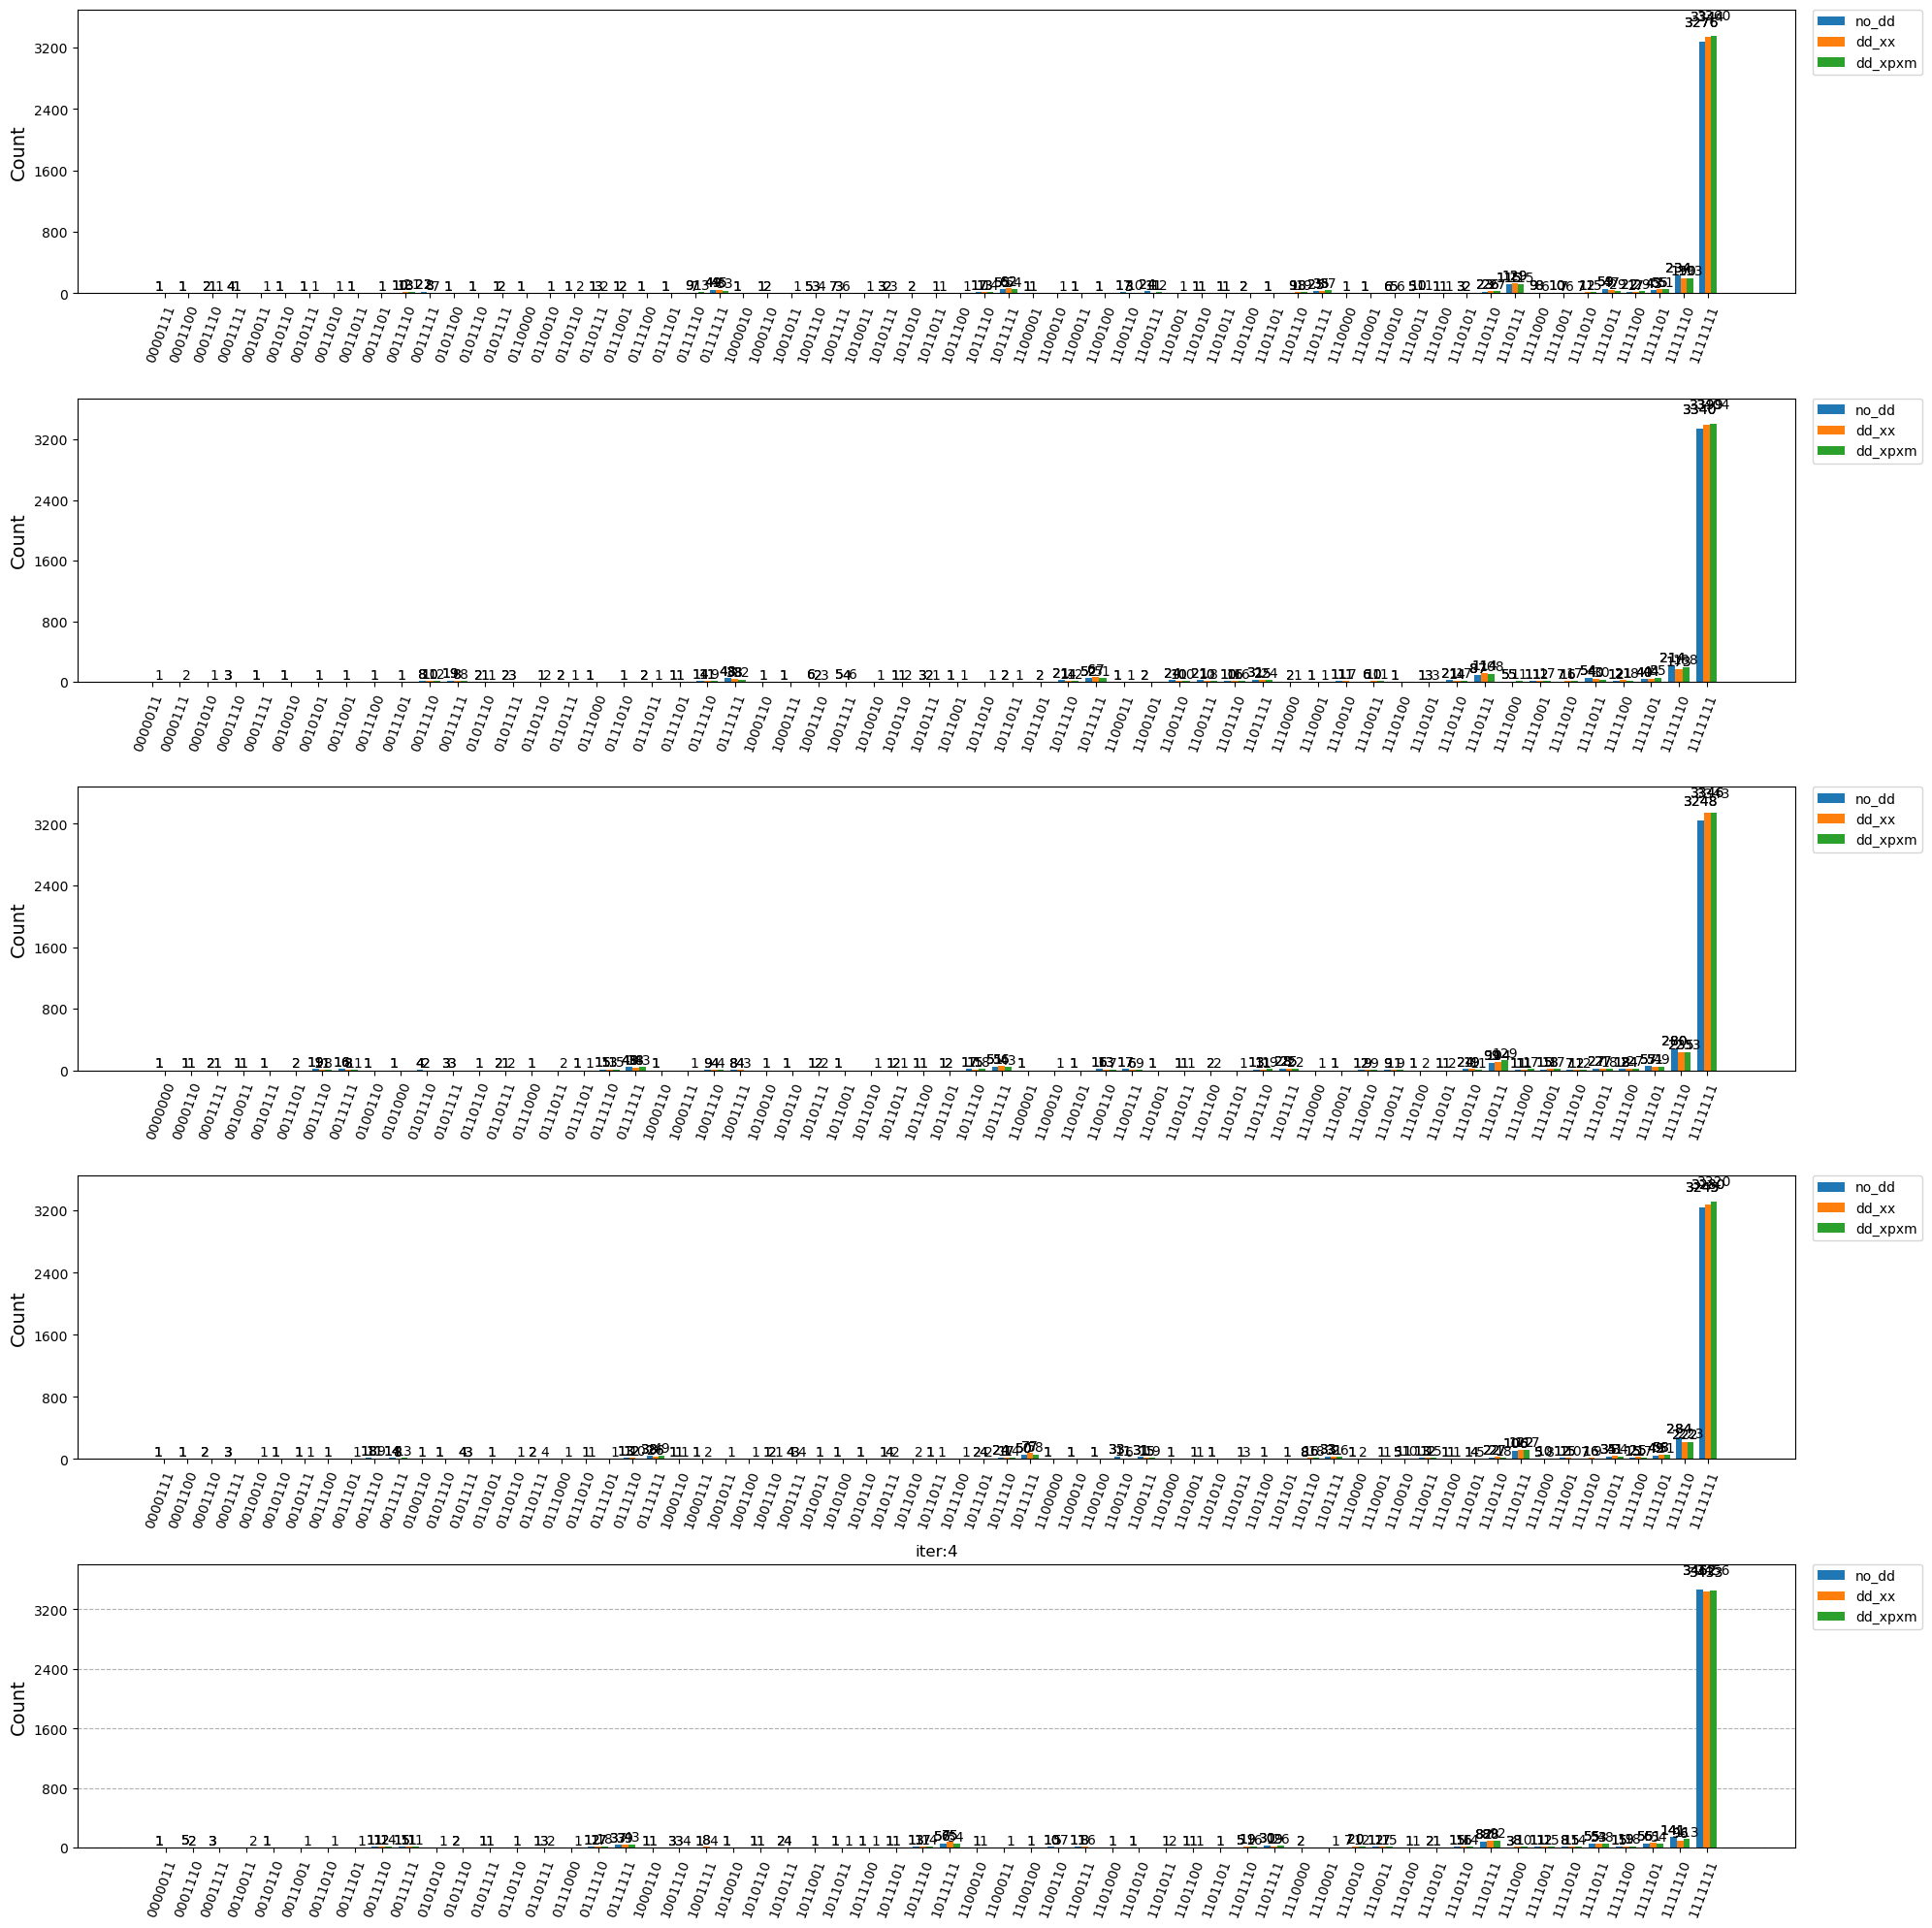

In [113]:
fig, ax = plot_all_counts(df, 7)


### Parse the results for plot

In [114]:
def view_results_and_convert_in_array(data, qubit):
    
    qubit_df = data[data["Qubit"] == qubit]

    simulated_data = []
    no_dd_data = []
    dd_xx_data = []
    dd_xpxm_data = []
    alt_no_dd_data = []
    alt_dd_xx_data = []
    alt_dd_xpxm_data = []

    for i in range(5):
        hf = qubit_df.iloc[i, 9]
        alt_hf = qubit_df.iloc[i, 10]
        print(f"For qubit: {qubit} \n Hellinger Fidelity wrt ideal (simulated, no_dd, dd):\n {hf} \n Hellinger Fidelity wrt simulated (no_dd, dd):\n {alt_hf} \n")
        
        simulated_data.append(hf[0])

        simulated_data.append(hf[0])
        no_dd_data.append(hf[1])
        dd_xx_data.append(hf[2])
        dd_xpxm_data.append(hf[3])
        alt_no_dd_data.append(alt_hf[0])
        alt_dd_xx_data.append(alt_hf[1])
        alt_dd_xpxm_data.append(alt_hf[2])    

    return [simulated_data, no_dd_data, dd_xx_data, dd_xpxm_data, alt_no_dd_data, alt_dd_xx_data, alt_dd_xpxm_data]



In [115]:
view_results_and_convert_in_array(df, 7)

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7998046875, 0.8164062500000001, 0.8203124999999999] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7998046875, 0.8164062500000001, 0.8203124999999999] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.8154296875, 0.829833984375, 0.8310546875000001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8154296875, 0.829833984375, 0.8310546875000001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7929687499999999, 0.81689453125, 0.816162109375] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7929687499999999, 0.81689453125, 0.816162109375] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.792236328125, 0.80078125, 0.810546875] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.792236328125, 0.80078125, 0.810546875] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.84521484375, 0.83813476

[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 [0.7998046875,
  0.8154296875,
  0.7929687499999999,
  0.792236328125,
  0.84521484375],
 [0.8164062500000001,
  0.829833984375,
  0.81689453125,
  0.80078125,
  0.838134765625],
 [0.8203124999999999,
  0.8310546875000001,
  0.816162109375,
  0.810546875,
  0.84375],
 [0.7998046875,
  0.8154296875,
  0.7929687499999999,
  0.792236328125,
  0.84521484375],
 [0.8164062500000001,
  0.829833984375,
  0.81689453125,
  0.80078125,
  0.838134765625],
 [0.8203124999999999,
  0.8310546875000001,
  0.816162109375,
  0.810546875,
  0.84375]]

In [116]:

data7  = view_results_and_convert_in_array(df, 7)[1:4]
data8  = view_results_and_convert_in_array(df, 8)[1:4]
data9  = view_results_and_convert_in_array(df, 9)[1:4]
data10 = view_results_and_convert_in_array(df, 10)[1:4]


For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7998046875, 0.8164062500000001, 0.8203124999999999] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7998046875, 0.8164062500000001, 0.8203124999999999] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.8154296875, 0.829833984375, 0.8310546875000001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8154296875, 0.829833984375, 0.8310546875000001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7929687499999999, 0.81689453125, 0.816162109375] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7929687499999999, 0.81689453125, 0.816162109375] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.792236328125, 0.80078125, 0.810546875] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.792236328125, 0.80078125, 0.810546875] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.84521484375, 0.83813476

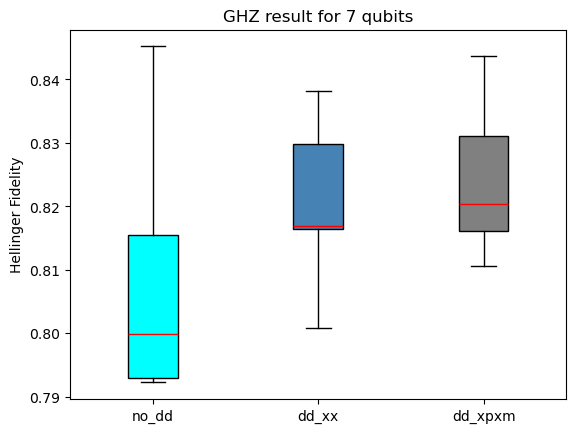

In [117]:
## For 7 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 7 qubits")

bplot = ax.boxplot(data7,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

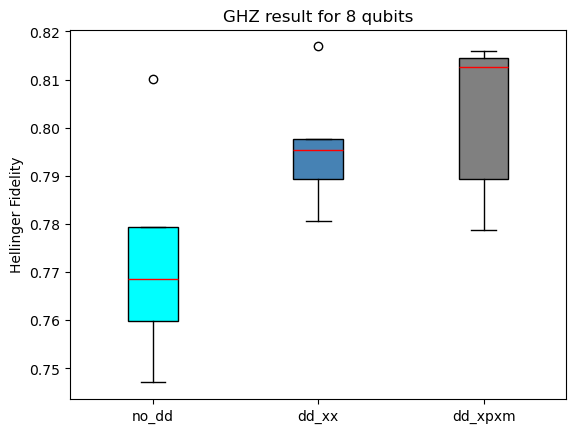

In [118]:
## For 8 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 8 qubits")

bplot = ax.boxplot(data8,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

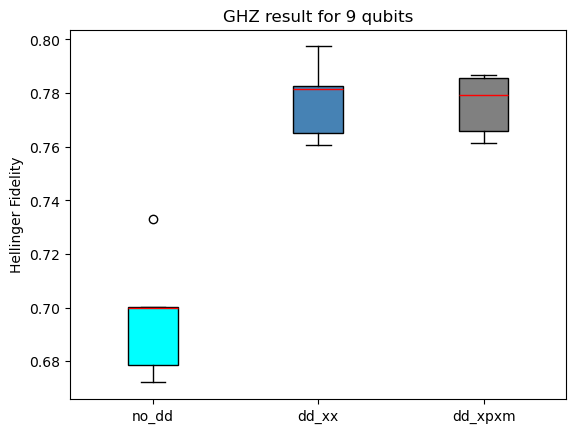

In [119]:
## For 9 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 9 qubits")

bplot = ax.boxplot(data9,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

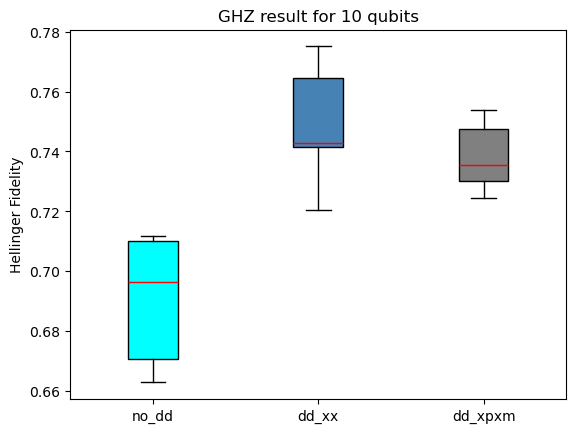

In [120]:
## For 10 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 10 qubits")

bplot = ax.boxplot(data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


plt.show()

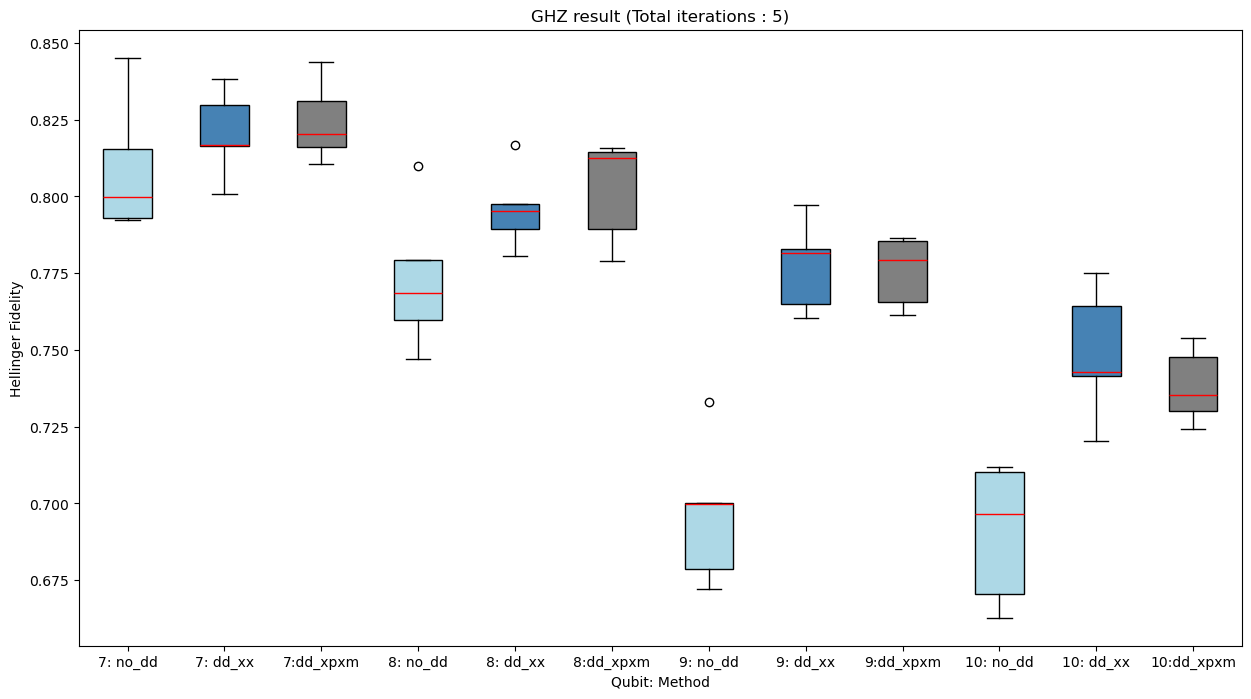

In [121]:
labels = ['7: no_dd', '7: dd_xx', '7:dd_xpxm', '8: no_dd', '8: dd_xx', '8:dd_xpxm', '9: no_dd', '9: dd_xx', '9:dd_xpxm', '10: no_dd', '10: dd_xx', '10:dd_xpxm']
colors = ['lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey']

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result (Total iterations : 5)")

bplot = ax.boxplot(data7+data8+data9+data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'), manage_ticks=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Qubit: Method")

plt.show()

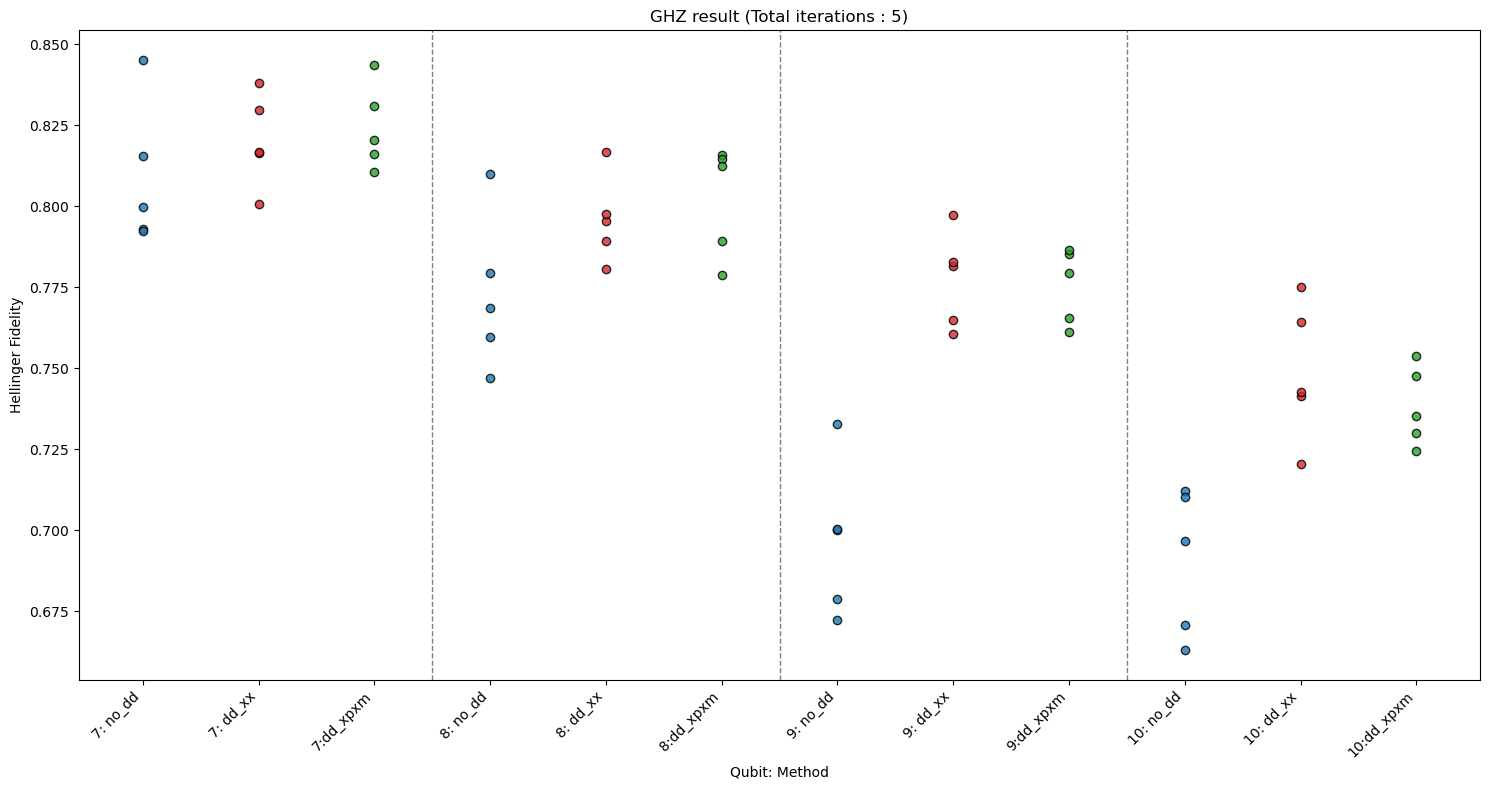

In [122]:
labels = ['7: no_dd', '7: dd_xx', '7:dd_xpxm', '8: no_dd', '8: dd_xx', '8:dd_xpxm',
          '9: no_dd', '9: dd_xx', '9:dd_xpxm', '10: no_dd', '10: dd_xx', '10:dd_xpxm']

# distinct, high-contrast colors cycling per trio
colors = ['#1f77b4', '#d62728', '#2ca02c'] * 4
datasets = data7 + data8 + data9 + data10  # list of arrays/lists

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result (Total iterations : 5)")
ax.set_xlabel("Qubit: Method")

for i, (vals, label, color) in enumerate(zip(datasets, labels, colors), start=1):
    x = np.full(len(vals), i)
    jitter = x  # small horizontal spread
    ax.scatter(x, vals, color=color, edgecolor='k', alpha=0.8, label=label if i == 1 else None)

# vertical separators between qubit groups (every 3 categories)
for pos in [3.5, 6.5, 9.5]:
    ax.axvline(pos, color='gray', linestyle='--', linewidth=1)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()
